In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import os
import sys
sys.path.append(os.path.abspath('..'))

plt.style.use('ggplot')

In [18]:
model = CatBoostClassifier()
model.load_model('../models/catboost_model.cbm')

feature_importance = model.get_feature_importance()
feature_name = model.feature_names_

importance_df = pd.DataFrame({
    'features': feature_name,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)
importance_df['importance'] = importance_df['importance'] / 100

print('Топ-10 самых важных признаков')
display(importance_df.head(10).round(4))

Топ-10 самых важных признаков


,features,importance
67,pre_util_min,0.1052
56,is_zero_loans530_mean,0.0508
139,enc_loans_credit_type_last,0.0452
68,pre_util_mean,0.0381
25,pre_loans_outstanding_min,0.0366
19,pre_loans_credit_limit_min,0.0293
36,pre_loans_credit_cost_rate_max,0.0283
59,is_zero_loans3060_mean,0.0274
130,enc_paym_23_nunique,0.0257
69,pre_util_max,0.0246


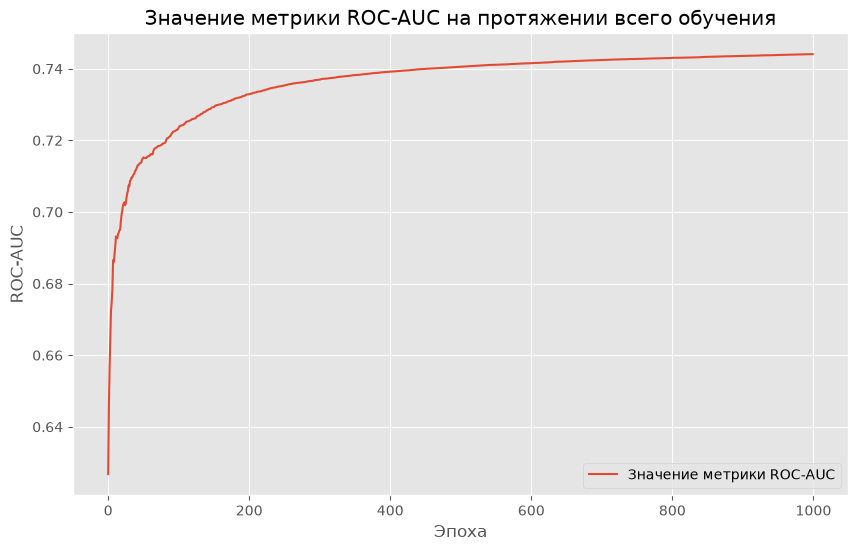

In [39]:
eval_result = model.get_evals_result()
val_auc_history = eval_result['validation']['AUC']

plt.figure(figsize=(10, 6))
sns.lineplot(data = val_auc_history, color='C0', label='Значение метрики ROC-AUC')
plt.legend(loc='lower right')
plt.title('Значение метрики ROC-AUC на протяжении всего обучения')
plt.xlabel('Эпоха')
plt.ylabel('ROC-AUC')
plt.show()